In [66]:
from json import load, loads, dump, dumps
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from scipy.ndimage import label

from collections import deque
from heapq import heappush, heappop

MAPSPATH = '../maps/'

DIRPATH = '../maps/path_planning_v4_shorter_distance/'
DIRPATH = '../maps/experiment_waffle_00/'
MAP_001 = 'map_20250330_222348_568341.json'

TEST_DIRPATH = '../maps/gimp_draw_maps/'
_map = 'test_generate.json'

VAL_FRONTIER = 2

VAL_UNKNOWN = -1
VAL_FREE = 0
VAL_OCCUPIED = 100
VAL_INACCESSIBLE = 101

VAL_CURR_POSITION = 102
VAL_NEXT_GOAL = 103

VAL_LARGEST_OBSTACLE = 104
VAL_CALCULATED_PATH = 99

PATH_LABEL_MIN = 20
PATH_LABEL_MAX = 29
EST_VIEW_MIN = 30
EST_VIEW_MAX = 39

SPECIAL_DONT_OVERWRITE = set([VAL_CURR_POSITION, VAL_NEXT_GOAL, VAL_LARGEST_OBSTACLE])
# SPECIAL_DONT_OVERWRITE = set([VAL_CURR_POSITION, VAL_NEXT_GOAL, VAL_LARGEST_OBSTACLE] + list(range(PATH_LABEL_MIN, EST_VIEW_MAX + 1)))

RESOLUTION_M = 0.05
ROBOT_RADIUS_M = 0.15
MAX_SPEED_MPS = 0.18

MAP_DUMP = True

colormap = {
    VAL_UNKNOWN: [0.5, 0.5, 0.5],  # Gray (unknown terrain)
    VAL_FREE: [1.0, 1.0, 1.0],  # White (blank space)
    VAL_OCCUPIED: [0.0, 0.0, 0.0],  # Black (walls)
    VAL_INACCESSIBLE: [0.0, 1.0, 0.0],  # Green (estimated walls)
    
    VAL_CURR_POSITION: [1.0, 0.0, 0.0],  # Red (current position)
    VAL_NEXT_GOAL: [0.0, 0.0, 1.0],  # Blue (next goal)
    VAL_FRONTIER: [1.0, 0.5, 0.0],  # Orange (estimated frontier)
    VAL_LARGEST_OBSTACLE: [1.0, 0.0, 1.0],  # Magenta (largest obstacle)
    VAL_CALCULATED_PATH: [0.498, 0.0, 1.0],  # Violet (calculated path)
}


# Gradient for 20–29 (next robot goals) → shades of Blue
colors_goal = plt.cm.Blues(np.linspace(0.3, 0.9, EST_VIEW_MIN-PATH_LABEL_MIN))[:, :3]  # lighter → darker blues
for i, rgb in enumerate(colors_goal, start=PATH_LABEL_MIN):
    colormap[i] = rgb.tolist()

# Gradient for 30–39 (visibility from goals) → shades of Orange
colors_vis = plt.cm.Oranges(np.linspace(0.3, 0.9, EST_VIEW_MIN-PATH_LABEL_MIN))[:, :3]  # lighter → darker oranges
for i, rgb in enumerate(colors_vis, start=EST_VIEW_MIN):
    colormap[i] = rgb.tolist()

RESOLUTION = 0.05  # meters per pixel


## Input and output

In [90]:
def read_data_map(_dir_path: str=DIRPATH, _map_path: str=MAP_001) -> tuple[np.ndarray[tuple[()], np.dtype], float, float]:
    """Reads map data from a JSON file and returns the grid, origin x, and origin y.
    Args:
        _dir_path (str, optional): Directory path to the map file. Defaults to DIRPATH.
        _map_path (str, optional): Map file name. Defaults to MAP_001.

    Returns:
        _type_: _description_
    """
    
    _data = dict()
    with open(_dir_path + '/' + _map_path, 'r+') as json_data:
        _data = load(json_data)
        json_data.close()
    
    try:
        _data = _data['map']
        # print(_data)

        width = _data['info']['width']
        height = _data['info']['height']
        origin_x = _data['info']['origin']['position']['x']
        origin_y = _data['info']['origin']['position']['y']
        _data = _data['data']

        grid = np.array(_data).reshape((height, width))

        return grid, origin_x, origin_y, _data

    except:
        print('No data found in the map file')
    
    return None, None, None, None

def read_data_odom(_dir_path: str=DIRPATH, _odom_path: str=MAP_001) -> tuple[int, int, list]:
    _data = dict()
    with open(_dir_path + '/' + _odom_path, 'r+') as json_data:
        _data = load(json_data)
        json_data.close()
    
    try:
        _data = _data['odom']
        # print(_data)

        x = _data['pose']['pose']['position']['x']
        y = _data['pose']['pose']['position']['y']

        return x, y, _data

    except:
        print('No data found in the odom file')
    
    return None, None, None

def read_frame(_dir_path: str=DIRPATH, _map_path: str=MAP_001, frame: str='map') -> tuple[np.ndarray[tuple[()], np.dtype], float, float]:
    """Reads map data from a JSON file and returns the grid, origin x, and origin y.
    Args:
        _dir_path (str, optional): Directory path to the map file. Defaults to DIRPATH.
        _map_path (str, optional): Map file name. Defaults to MAP_001.

    Returns:
        _type_: _description_
    """
    
    _data = dict()
    with open(_dir_path + '/' + _map_path, 'r+') as json_data:
        _data = load(json_data)
        json_data.close()
    
    try:
        _data = _data[frame]
        return _data
        
    except:
        print(f'No data found in the {_map_path}.{frame} file')
        
    return None
    

def print_plot_v2(
    grid: np.ndarray[tuple[()], np.dtype],
    title: str="Original map",
    filename: str="Not provided",
    occupied: int=-1,
    free: int=-1,
    inaccessible: int=-1,
    unknown: int=-1,
    explored_percent: float=-1.0,
    position_x: float=-1,
    position_y: float=-1) -> None:
    height, width = grid.shape
    colored_map = np.zeros((height, width, 3))

    for y in range(height):
        for x in range(width):
            color_code = grid[y, x]
            colored_map[y, x] = colormap[color_code]
            
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(colored_map, origin='upper')
    plt.title(title)
    plt.axis('off')
    
    legend_text = (f"Filename: {filename}\n"
                   f"Occupied: {occupied}\n"
                   f"Free: {free}\n"
                   f"Inaccessible: {inaccessible}\n"
                   f"Unknown: {unknown}\n"
                   f"Explored: {100*explored_percent:.8f}\n"
                   f"Position: {position_x:.4f}, {position_y:.4f}"
                   )
    
    plt.subplot(1, 2, 2)
    plt.axis('off')
    plt.text(0.1, 0.5, legend_text, fontsize=12, verticalalignment='center')
    
    plt.show()
    
    return

def print_space_estimation_charts(
    grid: np.ndarray[tuple[()], np.dtype],
    title: str = "Map Statistics",
    filename: str = "Not provided",
    occupied: int = -1,
    free: int = -1,
    inaccessible: int = -1,  # unused here
    unknown: int = -1,
    explored_percent: float = -1.0,
    position_x: float = -1,
    position_y: float = -1) -> None:
    
    height, width = grid.shape
    unknown_num = np.count_nonzero(grid == -1)
    to_be_explored_num = np.count_nonzero((grid >= 20) & (grid <= 39))
    known_num = width * height - unknown_num - to_be_explored_num

    # Prepare values for pie chart
    labels = ['Known', 'Unknown', 'Will be explored']
    values = [
        known_num,
        unknown_num,
        to_be_explored_num
    ]
    colors = [
        [0.0, 1.0, 0.0],
        [1.0, 0.5, 0.0],
        [0.0, 0.0, 1.0]
    ]

    plt.figure(figsize=(6, 6))
    plt.pie(values, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=90, counterclock=False)

    plt.title(f"{title}\n"
              f"Explored: {100*explored_percent:.2f}%\n"
            #   f"Pos: ({position_x:.2f}, {position_y:.2f})\n"
              f"File: {filename}")
    plt.tight_layout()
    plt.show()
    
def print_space_in_time_changes(maps_list: list[np.ndarray[tuple[()], np.dtype]], timestamps: list) -> None:
    explored_percents = []
    unknown_percents = []
    planned_percents = []
    
    boundary_found_timestep = -1

    for i, grid in enumerate(maps_list):
        # print(map_data)
        # height, width = map_data["info"]["height"], map_data["info"]["width"]
        # grid = np.array(map_data["data"]).reshape((height, width))
        occupied = np.count_nonzero(grid == VAL_OCCUPIED)
        free = np.count_nonzero(grid == VAL_FREE)
        inaccessible = np.count_nonzero(grid == VAL_INACCESSIBLE)
        unknown = np.count_nonzero(grid == VAL_UNKNOWN)
        planned = np.count_nonzero((grid >= 20) & (grid <= 39))
        total_cells = grid.size
        
        # timestamp = map_data["header"]["stamp"]["sec"]
        # timestamps.append(timestamp)
        
        explored_percent = (occupied + free + inaccessible) / total_cells
        explored_percents.append(explored_percent * 100)

        unknown_percent = (unknown) / total_cells
        unknown_percents.append(unknown_percent * 100)
        
        planned_percent = (planned) / total_cells
        planned_percents.append(planned_percent * 100)
        
        if boundary_found_timestep == -1 and planned > 0:
            boundary_found_timestep = timestamps[i-1]
            print(f"Boundary found at timestep: {boundary_found_timestep}")

    plt.figure(figsize=(10, 5))
    
    # plt.scatter(timestamps, explored_percents, marker='o')
    # plt.scatter(timestamps, unknown_percents, marker='o')
    # plt.scatter(timestamps, planned_percents, marker='o')
    
    # plt.plot(timestamps, explored_percents, marker='o')
    # plt.plot(timestamps, unknown_percents, marker='o')
    # plt.plot(timestamps, planned_percents, marker='o')
    
    # print('timestamps', len(timestamps))
    # print('grid', len(grid))
    # print('explored_percents', len(explored_percents))
    # print('unknown_percents', len(unknown_percents))
    # print('planned_percents', len(planned_percents))

    plt.step(timestamps, explored_percents, where='post')
    plt.step(timestamps, unknown_percents, where='post')
    plt.step(timestamps, planned_percents, where='post')
    
    plt.axvline(boundary_found_timestep, color='purple', linestyle='--', label='Boundary Found')

    
    plt.title('Explored Space Over Time')
    plt.xlabel('Time [s]')
    plt.ylabel('Explored Space (%)')
    plt.legend(['Explored', 'Unknown', 'Planned','Boundary Found'])
    
    
    plt.grid(True)
    plt.show()
    

def print_estimated_time_changes_v2(raw_times: list[dict[str:object]], timestamps=list[int], title_prefix=""):
    """
    Given a list over time steps, where each item is the times_between_points list
    returned by path_calculation for that step, compute:
      - total estimated remaining min/max time per step
      - actual completion time (first step with no goals -> len == 0)
      - estimation error per step: estimate_remaining - actual_remaining

    Plots two figures:
      1) Estimated remaining min/max time vs step (or time)
      2) Estimation error vs step (or time)

    Args:
      - times_list_per_dump: list of tuples (min_s, max_s)
      - step_times_s: list of cumulative times for each dump (same length); if None, uses indices
      - title_prefix: text prefix for plot titles
    """
    
    if not raw_times:
        print("No raw_times data provided. Exiting function.")
        return
    timestamps = timestamps[len(timestamps)-len(raw_times):]
    
    # Figure 1: estimated remaining times
    est_min, est_max, est_real = [], [], []
    for _t in raw_times:
        est_min.append(_t['total_min_time'])
        est_max.append(_t['total_max_time'])
        est_real.append(_t['total_real_time'])
    
    center_index = len(est_real) // 2
    # first_estimation_slope = (0 - est_real[0] + timestamps[0]) / (timestamps[-1] - timestamps[0])
    # center_estimation_slope = (0 - est_real[center_index] + timestamps[center_index]) / (timestamps[-1] - timestamps[center_index])
    
    print("est_min", est_min)
    print("est_max", est_max)
    print("est_real", est_real)

    plt.figure(figsize=(10, 5))
    plt.plot(timestamps, est_min, label="Estimated min remaining (s)", color="tab:green")
    plt.plot(timestamps, est_real, label="Estimated real remaining (s)", color="tab:blue")
    plt.plot(timestamps, est_max, label="Estimated max remaining (s)", color="tab:orange")
    
    plt.axline((timestamps[0], est_real[0]), (timestamps[0] + est_real[0], 0), color="tab:purple", linestyle="--", label="First estimation slope")
    plt.axline((timestamps[center_index], est_real[center_index]), (timestamps[center_index] + est_real[center_index], 0), color="tab:brown", linestyle="--", label="Center estimation slope")
    # if finish_idx is not None:
    #     plt.axvline(x=x[finish_idx], color="tab:green", linestyle="--", label="Completion")
    plt.xlabel("Step" if timestamps is None else "Time (s)")
    plt.ylabel("Remaining time (s)")
    plt.title(f"{title_prefix} Estimated Remaining Time")
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    exploration_completed_timestamp = timestamps[-1]
    timestamp_differences = [exploration_completed_timestamp - ts for ts in timestamps]
    
    # Figure 2: estimation absolute error
    
    err_abs_min = [abs(est_min[i] - timestamp_differences[i]) for i in range(len(est_min))]
    err_abs_max = [abs(est_max[i] - timestamp_differences[i]) for i in range(len(est_max))]
    err_abs_real = [abs(est_real[i] - timestamp_differences[i]) for i in range(len(est_real))]
    
    print("err_abs_min", err_abs_min)
    print("err_abs_max", err_abs_max)
    print("err_abs_real", err_abs_real)
    print("timestamp_differences", timestamp_differences)

    plt.figure(figsize=(10, 5))
    if err_abs_min is not None and err_abs_max is not None and err_abs_real is not None:
        plt.plot(timestamps, err_abs_min, label="Error (min estimate)", color="tab:green")
        plt.plot(timestamps, err_abs_real, label="Error (real estimate)", color="tab:blue")
        plt.plot(timestamps, err_abs_max, label="Error (max estimate)", color="tab:orange")
        plt.axhline(0.0, color="k", linewidth=1)
        # plt.axvline(x=x[finish_idx], color="tab:green", linestyle="--", label="Completion")
        plt.ylabel("Error (s)")
        plt.title(f"{title_prefix} Absolute Estimation Error vs Actual Remaining Time")
        plt.legend()
    else:
        plt.text(0.5, 0.5, "Completion not observed; error cannot be computed.",
                 ha="center", va="center", transform=plt.gca().transAxes)
        plt.title(f"{title_prefix} Estimation Error")
    plt.xlabel("Step" if timestamps is None else "Time (s)")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    # Figure 3: estimation relative error
    
    err_rel_min = [err_abs_min[i] / timestamp_differences[i] * 100 for i in range(len(err_abs_min) -1)] + [0]
    err_rel_max = [err_abs_max[i] / timestamp_differences[i] * 100 for i in range(len(err_abs_max) -1)] + [0]
    err_rel_real = [err_abs_real[i] / timestamp_differences[i] * 100 for i in range(len(err_abs_real) -1)] + [0]
    
    print("err_abs_min", err_rel_min)
    print("err_abs_max", err_rel_max)
    print("err_abs_real", err_rel_real)
    print("timestamp_differences", timestamp_differences)
    
    plt.figure(figsize=(10, 5))
    if err_rel_min is not None and err_rel_max is not None and err_rel_real is not None:
        plt.plot(timestamps, err_rel_min, label="Error (min estimate)", color="tab:green")
        plt.plot(timestamps, err_rel_max, label="Error (real estimate)", color="tab:blue")
        plt.plot(timestamps, err_rel_real, label="Error (max estimate)", color="tab:orange")
        plt.axhline(0.0, color="k", linewidth=1)
        # plt.axvline(x=x[finish_idx], color="tab:green", linestyle="--", label="Completion")
        plt.ylabel("Error (%)")
        plt.title(f"{title_prefix} Relative Estimation Error vs Actual Remaining Time")
        plt.legend()
    else:
        plt.text(0.5, 0.5, "Completion not observed; error cannot be computed.",
                 ha="center", va="center", transform=plt.gca().transAxes)
        plt.title(f"{title_prefix} Estimation Error")
    plt.xlabel("Step" if timestamps is None else "Time (s)")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    

## Space estimation

In [45]:
def get_reachable_mask(grid: np.ndarray, position: tuple[int, int]) -> np.ndarray[tuple[()], np.dtype]:
    h, w = grid.shape
    visited = np.zeros_like(grid, dtype=bool)
    q = deque([position])
    visited[position[1], position[0]] = True
    
    while q:
        x, y = q.popleft()
        for dx, dy in [(-1,0),(1,0),(0,-1),(0,1)]:
            nx, ny = x + dx, y + dy
            if 0 <= nx < w and 0 <= ny < h:
                if not visited[ny, nx] and grid[ny, nx] in [0, -1] + [i for i in range(PATH_LABEL_MIN, EST_VIEW_MAX+1)]:
                    visited[ny, nx] = True
                    q.append((nx, ny))

    return visited


In [46]:
def fill_outside_with_val_inaccessible(grid: np.ndarray, position: tuple[int, int]) -> np.ndarray[tuple[()], np.dtype]:
    reachable = get_reachable_mask(grid, position)
    grid[(grid == -1) & (~reachable)] = VAL_INACCESSIBLE
    
    return grid

def is_fully_enclosed(grid: np.ndarray, position: tuple[int, int]) -> bool:
    reachable = get_reachable_mask(grid, position)
    unknown_mask = (grid == -1)
    
    return not np.any(reachable & unknown_mask)

def is_fully_enclosed_v2(
    grid: np.ndarray,
    position: tuple[int, int],
    free_val: int = VAL_FREE,
    unknown_val: int = VAL_UNKNOWN,
    occupied_val: int = VAL_OCCUPIED
) -> bool:
    """
    Check if the robot's current free-space region is fully enclosed.
    The area is considered enclosed if no path exists from the current cell
    to any unknown cell.

    Args:
        grid (np.ndarray): occupancy grid (2D array).
        position (tuple[int,int]): (row, col) position of the robot.
        free_val (int): value representing free cells.
        unknown_val (int): value representing unknown cells.
        occupied_val (int): value representing occupied cells.

    Returns:
        bool: True if fully enclosed (no path to unknown), False otherwise.
    """
    rows, cols = grid.shape
    visited = np.zeros_like(grid, dtype=bool)

    q = [position]
    visited[position[0], position[1]] = True

    # 8-connected search
    directions = [(1,0),(-1,0),(0,1),(0,-1),(1,1),(-1,-1),(1,-1),(-1,1)]

    while q:
        x, y = q.pop(0)
        for dx, dy in directions:
            nx, ny = x + dx, y + dy
            if 0 <= nx < rows and 0 <= ny < cols and not visited[nx, ny]:
                if grid[nx, ny] == unknown_val:
                    return False  # found escape path
                if grid[nx, ny] == free_val:
                    visited[nx, ny] = True
                    q.append((nx, ny))
    return True


def fill_enclosed_unknowns_v2(grid: np.ndarray, position: tuple[int, int]) -> np.ndarray[tuple[()], np.dtype]:
    reachable = get_reachable_mask(grid, position)
    unknown = (grid == -1)
    enclosed = unknown & (~reachable)
    grid[enclosed] = VAL_INACCESSIBLE
    
    return grid

def fill_boundary_unknowns(grid: np.ndarray, position: tuple[int, int]) -> np.ndarray[tuple[()], np.dtype]:
    reachable = get_reachable_mask(grid, position)
    h, w = grid.shape
    for y in range(h):
        for x in range(w):
            if grid[y, x] == -1 and reachable[y, x]:
                neighbors = [(x+dx, y+dy) for dx, dy in [(-1,0),(1,0),(0,-1),(0,1)]]
                if any(0 <= nx < w and 0 <= ny < h and grid[ny, nx] == 0 for nx, ny in neighbors):
                    grid[y, x] = 0
    
    return grid

def fill_boundary_gaps(grid: np.ndarray, position: tuple[int, int]) -> np.ndarray[tuple[()], np.dtype]:
    reachable = get_reachable_mask(grid, position)
    h, w = grid.shape
    for y in range(h):
        for x in range(w):
            if grid[y, x] == -1 and reachable[y, x]:
                neighbors = [(x+dx, y+dy) for dx, dy in [(-1,0),(1,0),(0,-1),(0,1)]]
                free_neighbors = [grid[ny, nx] == 0 for nx, ny in neighbors if 0 <= nx < w and 0 <= ny < h]
                if sum(free_neighbors) >= 2:
                    grid[y, x] = 0
    
    return grid


In [47]:
def calculate_remaining_space(grid: np.ndarray[tuple[()], np.dtype]) -> tuple:

    _explored_num = np.count_nonzero(grid==VAL_OCCUPIED) + np.count_nonzero(grid==VAL_FREE) + np.count_nonzero(grid==VAL_INACCESSIBLE)
    _height, _width = grid.shape
    # print(_width, _height, _width*_height, _explored_num)
    _explored_percent = _explored_num / (_width * _height)
    # print('explored %f not explored %f', _explored_percent, 1.0-_explored_percent)
    
    return np.count_nonzero(grid==VAL_OCCUPIED),\
        np.count_nonzero(grid==VAL_FREE),\
        np.count_nonzero(grid==VAL_INACCESSIBLE),\
        np.count_nonzero(VAL_UNKNOWN),\
        _explored_percent

## Exploration

In [48]:
def get_position(x: float, y: float, origin_x: float = 0.0, origin_y: float = 0.0) -> tuple[int, int]:
    """Get position in pixels from real-world coordinates.

    Args:
        x (float), y (float): Real-world coordinates to mark.
        origin_x (float, optional), origin_y (float, optional): Real-world coordinates of the map's origin (bottom-left corner). Defaults to 0.0.

    Returns:
        tuple: position x and y in pixels
    """
    
    return int((x - origin_x) / RESOLUTION), int((y - origin_y) / RESOLUTION)

def mark_position(
    grid: np.ndarray,
    x: float,
    y: float,
    origin_x: float = 0.0,
    origin_y: float = 0.0
    ) -> np.ndarray:
    """
    Marks a position on the grid based on real-world coordinates and map origin.

    Args:
        grid: 2D numpy array representing the map.
        x, y: Real-world coordinates to mark.
        origin_x, origin_y: Real-world coordinates of the map's origin (bottom-left corner).

    Returns:
        Modified grid with the position marked.
    """
    height, width = grid.shape

    # Convert world coordinates to pixel indices
    x_pixel, y_pixel = get_position(x, y, origin_x, origin_y)

    print(f"Marking position at world coordinates: ({x}, {y})")
    print(f"Converted to pixel coordinates: ({x_pixel}, {y_pixel})")

    if 0 <= x_pixel < width and 0 <= y_pixel < height:
        grid[y_pixel, x_pixel] = VAL_CURR_POSITION
    else:
        print("Warning: Position out of grid bounds.")

    return grid

def mark_position_v2(
    grid: np.ndarray,
    x: int,
    y: int,
    color: int = VAL_CURR_POSITION
    ) -> np.ndarray:
    """
    Marks a position on the grid based on real-world coordinates and map origin.

    Args:
        grid: 2D numpy array representing the map.
        x, y: grid coordinates.

    Returns:
        Modified grid with the position marked.
    """
    height, width = grid.shape

    # print(f"Marking position at world coordinates: ({x}, {y})")

    if 0 <= x < width and 0 <= y < height:
        grid[y, x] = color
    else:
        print("Warning: Position out of grid bounds.")

    return grid


In [49]:
def explore_nearest_unknown(
    grid: np.ndarray,
    x: float,
    y: float,
    origin_x: float = 0.0,
    origin_y: float = 0.0,
    resolution: float = 1.0
) -> tuple[float | None, float | None, int | None, int | None]:
    """
    Navigate to the nearest unknown (-1) cell.

    Parameters:
        grid (np.ndarray): Occupancy grid (2D)
        x (float): Robot real-world x position
        y (float): Robot real-world y position
        origin_x (float): Map origin x in real-world coordinates
        origin_y (float): Map origin y in real-world coordinates
        resolution (float): Map resolution (m/cell)

    Returns:
        Tuple of real-world coordinates (x, y) and grid coordinates (x, y) or None if no unknowns found
    """
    height, width = grid.shape

    # Convert real-world position to grid indices
    grid_x = int((x - origin_x) / resolution)
    grid_y = int((y - origin_y) / resolution)

    # Validate bounds
    if not (0 <= grid_x < width and 0 <= grid_y < height):
        raise ValueError("Robot position is out of map bounds")

    # Find all unknown cells
    unknown_indices = np.argwhere(grid == -1)
    if unknown_indices.size == 0:
        return None, None, None, None

    # Compute distances
    distances = np.linalg.norm(unknown_indices - np.array([grid_y, grid_x]), axis=1)
    nearest_idx = unknown_indices[np.argmin(distances)]

    # Convert grid indices back to real-world coordinates
    target_real_x = origin_x + nearest_idx[1] * resolution + resolution / 2
    target_real_y = origin_y + nearest_idx[0] * resolution + resolution / 2

    return (target_real_x, target_real_y, nearest_idx[1], nearest_idx[0])

# copilot generated for fun - will not be used
def get_wall_estimation(grid: np.ndarray, position: tuple[int, int]) -> np.ndarray[tuple[()], np.dtype]:
    h, w = grid.shape
    visited = np.zeros_like(grid, dtype=bool)
    q = deque([position])
    visited[position[1], position[0]] = True
    
    while q:
        x, y = q.popleft()
        for dx, dy in [(-1,0),(1,0),(0,-1),(0,1)]:
            nx, ny = x + dx, y + dy
            if 0 <= nx < w and 0 <= ny < h:
                if not visited[ny, nx] and grid[ny, nx] == VAL_UNKNOWN:
                    visited[ny, nx] = True
                    q.append((nx, ny))

    return visited


## Time Estimation

In [50]:
def _inflate_obstacles_chebyshev(mask: np.ndarray, radius_cells: int) -> np.ndarray:
    """
    Inflate a boolean obstacle mask using Chebyshev (8-connected) radius via
    repeated shifts/OR. radius_cells is inclusive (cells with max(|dx|,|dy|) <= radius_cells).
    """
    if radius_cells <= 0:
        return mask.copy()
    h, w = mask.shape
    inflated = mask.copy()
    for dy in range(-radius_cells, radius_cells + 1):
        for dx in range(-radius_cells, radius_cells + 1):
            if max(abs(dx), abs(dy)) <= radius_cells:
                ys = slice(max(0, -dy), min(h, h - dy))
                yd = slice(max(0, dy), min(h, h + dy))
                xs = slice(max(0, -dx), min(w, w - dx))
                xd = slice(max(0, dx), min(w, w + dx))
                if ys.stop > ys.start and xs.stop > xs.start:
                    inflated[yd, xd] |= mask[ys, xs]
    return inflated


def _astar_path(start_rc, goal_set, blocked_mask, allow_diagonal=True, debug: bool=False):
    """
    A* from start_rc (row, col) to any cell in goal_set (set of (r,c)),
    avoiding True in blocked_mask. Prevents diagonal corner cutting.
    Returns list of (r, c) cells including start and goal. If no path, returns None.
    """
    h, w = blocked_mask.shape

    if not goal_set:
        if debug: print("A* called with empty goal set")
        return None
    if blocked_mask[start_rc]:
        if debug: print("A* called with start in blocked cell")
        return None

    # Precompute a list of goal coords and a quick membership test
    goal_set = set([(int(r), int(c)) for (r, c) in goal_set if 0 <= r < h and 0 <= c < w and not blocked_mask[r, c]])
    if not goal_set:
        if debug: print("A* called with no reachable goals")
        return None

    # Movements
    if allow_diagonal:
        moves = [(-1, 0, 1.0), (1, 0, 1.0), (0, -1, 1.0), (0, 1, 1.0),
                 (-1, -1, np.sqrt(2)), (-1, 1, np.sqrt(2)),
                 (1, -1, np.sqrt(2)), (1, 1, np.sqrt(2))]
    else:
        moves = [(-1, 0, 1.0), (1, 0, 1.0), (0, -1, 1.0), (0, 1, 1.0)]

    def heuristic(r, c):
        # Euclidean distance to the closest goal
        # To keep it efficient, approximate by min over bounding box if needed;
        # here we do a simple min over a sampled subset if set is large.
        # For moderate sets, exact min is fine.
        hr = None
        # Simple heuristic: pick centroid of goals for speed
        # (still admissible if using Euclidean to centroid? Not strictly)
        # To stay admissible, use minimum Chebyshev distance to a few sampled goals.
        # For simplicity, compute EUC to a handful of goals and take min.
        sample = 64
        if len(goal_set) <= sample:
            goals_iter = goal_set
        else:
            # sample some goals deterministically
            steps = max(1, len(goal_set) // sample)
            goals_iter = [g for i, g in enumerate(goal_set) if i % steps == 0]
        dmin = float('inf')
        for (gr, gc) in goals_iter:
            dr = gr - r
            dc = gc - c
            d = (dr * dr + dc * dc) ** 0.5
            if d < dmin:
                dmin = d
        return dmin

    start = (int(start_rc[0]), int(start_rc[1]))

    # A*
    open_heap = []
    heappush(open_heap, (heuristic(*start), 0.0, start))
    g_cost = {start: 0.0}
    came_from = {}

    visited = set()

    while open_heap:
        f, g, current = heappop(open_heap)
        if current in visited:
            continue
        visited.add(current)

        if current in goal_set:
            # reconstruct
            path = [current]
            while current in came_from:
                current = came_from[current]
                path.append(current)
            path.reverse()
            return path

        cr, cc = current
        for dr, dc, step_cost in moves:
            nr, nc = cr + dr, cc + dc
            if nr < 0 or nr >= h or nc < 0 or nc >= w:
                continue
            # Prevent diagonal corner cutting
            if dr != 0 and dc != 0:
                if blocked_mask[cr, cc + dc] or blocked_mask[cr + dr, cc]:
                    continue
            if blocked_mask[nr, nc]:
                continue

            new_g = g + step_cost
            nxt = (nr, nc)
            if nxt not in g_cost or new_g < g_cost[nxt]:
                g_cost[nxt] = new_g
                came_from[nxt] = current
                heappush(open_heap, (new_g + heuristic(nr, nc), new_g, nxt))

    return None


def _find_single_cell(grid: np.ndarray, value: int):
    coords = np.argwhere(grid == value)
    if coords.size == 0:
        return None
    # If multiple, choose first
    r, c = coords[0]
    return (int(r), int(c))


def _collect_goal_region(grid: np.ndarray, label_value: int):
    coords = np.argwhere(grid == label_value)
    return set((int(r), int(c)) for r, c in coords)


def _count_turns(path_rc):
    """
    Count the number of direction changes along the path.
    Path is list of (r,c). A single-step path has 0 turns.
    """
    if path_rc is None or len(path_rc) < 3:
        return 0
    turns = 0
    prev_dir = (path_rc[1][0] - path_rc[0][0], path_rc[1][1] - path_rc[0][1])
    for i in range(1, len(path_rc) - 1):
        curr_dir = (path_rc[i + 1][0] - path_rc[i][0], path_rc[i + 1][1] - path_rc[i][1])
        if curr_dir != prev_dir:
            turns += 1
        prev_dir = curr_dir
    return turns


def path_drawing_v2(
    filled_grid: np.ndarray,
    resolution_m: float,
    robot_radius_m: float,
    max_speed_mps: float,
    consider_unknown_as_obstacle: bool = False,
    allow_diagonal: bool = True,
    debug: bool = False
) -> tuple[np.ndarray, list[tuple[float, float]]]:
    """
    Plans a collision-free path on the inflated occupancy grid from the current robot
    position (VAL_CURR_POSITION) to waypoints labeled PATH_LABEL_MIN..PATH_LABEL_MAX in
    ascending order. Marks the path with CALCULATED_PATH = 99 (does not overwrite special labels).

    Returns:
      - updated_grid: np.ndarray (copy with path overlaid)
      - times_between_points: list of (min_time_s, max_time_s) for each segment
    """
    grid = filled_grid.copy()
    h, w = grid.shape

    # Build blocked mask
    blocked = (grid == VAL_OCCUPIED) | (grid == VAL_INACCESSIBLE)
    if consider_unknown_as_obstacle:
        blocked |= (grid == VAL_UNKNOWN)

    # Inflate obstacles by robot radius
    radius_cells = int(np.ceil(robot_radius_m / max(1e-9, resolution_m)))
    # print("Inflating obstacles by radius (cells): ", radius_cells)
    blocked_inflated = _inflate_obstacles_chebyshev(blocked, radius_cells)
    # print("blocked cells: ", np.count_nonzero(blocked_inflated))

    # Find current position
    start_rc = _find_single_cell(grid, VAL_CURR_POSITION)
    if start_rc is None:
        if debug: print("Current position not found in grid, returning empty path.")
        # If current position is not marked, return unchanged grid and empty times
        return grid, []

    # Collect ordered waypoint label values that appear in the grid
    labels_present = []
    for label in range(PATH_LABEL_MIN, PATH_LABEL_MAX + 1):
        if np.count_nonzero((grid >= PATH_LABEL_MIN) & (grid <= PATH_LABEL_MAX)):
            labels_present.append(label)
            
    # print("labels_present: ", labels_present)

    times_between_points = []
    current_rc = start_rc

    for label in labels_present:
        goal_set = _collect_goal_region(grid, label)
        # Remove blocked goals (on inflated obstacles)
        # goal_set = set([rc for rc in goal_set if not blocked_inflated[rc]])
        if not goal_set:
            if debug: print(f"No reachable cells for label {label}, skipping.")
            # No reachable cells for this label; skip or break
            # Here we skip to try next labels; alternatively, break.
            continue

        path_rc = _astar_path(current_rc, goal_set, blocked_inflated, allow_diagonal=allow_diagonal, debug=debug)
        if path_rc is None:
            if debug: print(f"No path found to label {label}, skipping.")
            # No path to this label; skip to next
            continue

        # Compute path length (in meters) and turns
        path_len_cells = 0.0
        for i in range(len(path_rc) - 1):
            dr = path_rc[i + 1][0] - path_rc[i][0]
            dc = path_rc[i + 1][1] - path_rc[i][1]
            step = np.sqrt(2.0) if (dr != 0 and dc != 0) else 1.0
            path_len_cells += step
        path_len_m = path_len_cells * resolution_m

        n_turns = _count_turns(path_rc)
        min_time_s = path_len_m / max(1e-9, max_speed_mps)
        # Upper estimate: add one cell-travel time per turn
        max_time_s = min_time_s + n_turns * (resolution_m / max(1e-9, max_speed_mps))
        times_between_points.append((min_time_s, max_time_s))

        # Draw path on grid with CALCULATED_PATH without overwriting special markers
        for (r, c) in path_rc:
            val = grid[r, c]
            if val in SPECIAL_DONT_OVERWRITE:
                # print(f"Skipping cell ({r}, {c}) with special value {val}")
                continue
            grid[r, c] = VAL_CALCULATED_PATH

        # Move current position to the end of this segment
        current_rc = path_rc[-1]

    return grid, times_between_points


def print_estimated_time_changes(times_list_per_dump: list[tuple[float, float]], step_times_s=list[int], title_prefix=""):
    """
    Given a list over time steps, where each item is the times_between_points list
    returned by path_calculation for that step, compute:
      - total estimated remaining min/max time per step
      - actual completion time (first step with no goals -> len == 0)
      - estimation error per step: estimate_remaining - actual_remaining

    Plots two figures:
      1) Estimated remaining min/max time vs step (or time)
      2) Estimation error vs step (or time)

    Args:
      - times_list_per_dump: list of tuples (min_s, max_s)
      - step_times_s: list of cumulative times for each dump (same length); if None, uses indices
      - title_prefix: text prefix for plot titles
    """
    n = len(times_list_per_dump)
    if step_times_s is None:
        x = np.arange(n)
    else:
        x = np.asarray(step_times_s)
        if x.shape[0] != n:
            raise ValueError("step_times_s length must match times_list_per_dump length")

    # Total estimated remaining time per step
    est_min = [] # np.zeros(n, dtype=float)
    est_max = [] # np.zeros(n, dtype=float)
    planned_times = []
    estimeted_time_dumps = []
    for i, lst in enumerate(times_list_per_dump):
        if len(lst) != 0:
            # est_min[i] = 0.0
            # est_max[i] = 0.0
        # else:
            mins = [t[0] for t in lst if t is not None]
            maxs = [t[1] for t in lst if t is not None]
            # est_min[i] = np.sum(mins) if mins else 0.0
            # est_max[i] = np.sum(maxs) if maxs else 0.0
            est_min.append(np.sum(mins)) # if mins else 0.0
            est_max.append(np.sum(maxs)) # if maxs else 0.0
            planned_times.append(step_times_s[i])
            estimeted_time_dumps.append(lst)
    
    est_min = np.asarray(est_min)
    est_max = np.asarray(est_max)
    planned_times = np.asarray(planned_times)
    estimeted_time_dumps = np.asarray(estimeted_time_dumps, dtype=object)

    # Determine actual completion time as first index where no goals remain
    finish_idx = None
    for i, lst in enumerate(estimeted_time_dumps):
        if len(lst) != 0:
            finish_idx = i
            # break

    if finish_idx is not None:
        T_actual = planned_times[finish_idx]
        err_min = (planned_times + est_min - T_actual) / (planned_times - T_actual) * 100
        err_max = (planned_times + est_max - T_actual) / (planned_times - T_actual) * 100
    else:
        # Not completed in the provided data
        T_actual = None
        err_min = None
        err_max = None

    # Figure 1: estimated remaining times
    plt.figure(figsize=(10, 5))
    plt.plot(planned_times, est_min, label="Estimated min remaining (s)", color="tab:blue")
    plt.plot(planned_times, est_max, label="Estimated max remaining (s)", color="tab:orange")
    # if finish_idx is not None:
    #     plt.axvline(x=x[finish_idx], color="tab:green", linestyle="--", label="Completion")
    plt.xlabel("Step" if step_times_s is None else "Time (s)")
    plt.ylabel("Remaining time (s)")
    plt.title(f"{title_prefix} Estimated Remaining Time")
    plt.grid(True, alpha=0.3)
    plt.legend()

    # Figure 2: estimation error
    plt.figure(figsize=(10, 5))
    if err_min is not None:
        plt.plot(planned_times, err_min, label="Error (min estimate)", color="tab:blue")
        plt.plot(planned_times, err_max, label="Error (max estimate)", color="tab:orange")
        plt.axhline(0.0, color="k", linewidth=1)
        # plt.axvline(x=x[finish_idx], color="tab:green", linestyle="--", label="Completion")
        plt.ylabel("Error (%)")
        plt.title(f"{title_prefix} Estimation Error vs Actual Remaining Time")
        plt.legend()
    else:
        plt.text(0.5, 0.5, "Completion not observed; error cannot be computed.",
                 ha="center", va="center", transform=plt.gca().transAxes)
        plt.title(f"{title_prefix} Estimation Error")
    plt.xlabel("Step" if step_times_s is None else "Time (s)")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

## Another test

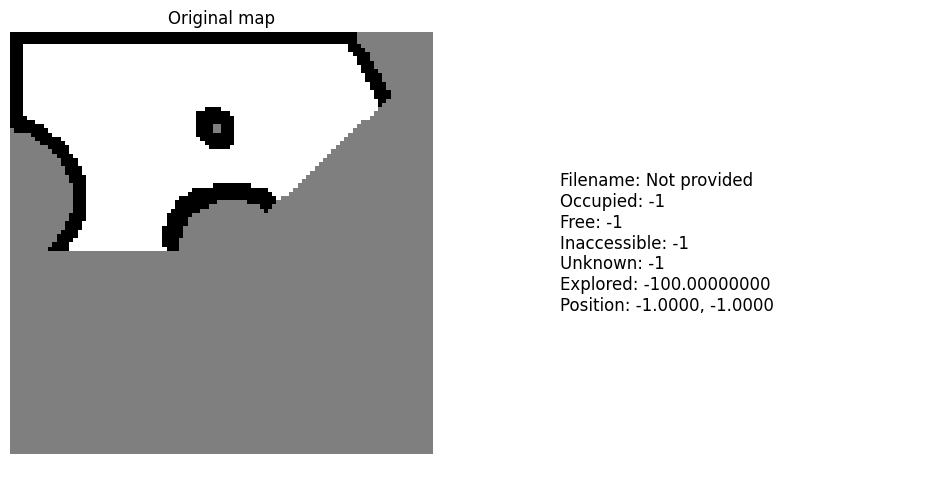

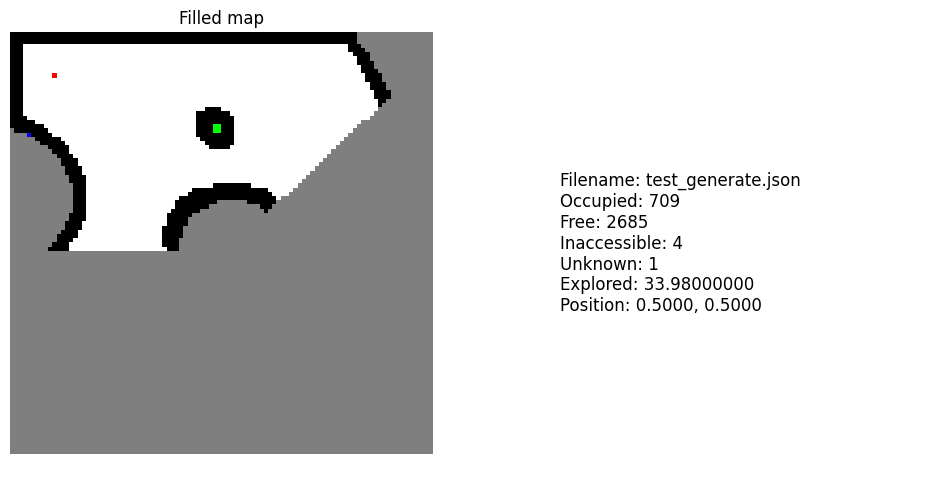

In [51]:
# print(TEST_MAP_001)
_grid, origin_x, origin_y, _ = read_data_map(TEST_DIRPATH, _map)
pos_x, pos_y, _ = read_data_odom(TEST_DIRPATH, _map)
position = get_position(pos_x, pos_y, origin_x, origin_y)

print_plot_v2(_grid, title="Original map")

filled_grid = fill_enclosed_unknowns_v2(_grid, position)
fully_enclosed = is_fully_enclosed(filled_grid, position)
# print(fully_enclosed, TEST_MAP_001)
if fully_enclosed:
    filled_grid = fill_outside_with_val_inaccessible(filled_grid, position)

# filled_grid = mark_position(filled_grid, pos_x, pos_y, origin_x, origin_y)

filled_grid = mark_position_v2(filled_grid, position[0], position[1], VAL_CURR_POSITION)
_,_, goal_x, goal_y = explore_nearest_unknown(filled_grid, position[0], position[1], origin_x, origin_y)
if goal_x is not None and goal_y is not None:
    filled_grid = mark_position_v2(filled_grid, goal_x, goal_y, VAL_NEXT_GOAL)
else:
    print("No unknowns found")

occupied,\
free,\
inaccessible,\
unknown,\
explored_percent = calculate_remaining_space(filled_grid)
print_plot_v2(
    filled_grid,
    title=f"Filled map",
    filename=_map,
    occupied=occupied,
    free=free,
    inaccessible=inaccessible,
    unknown=unknown,
    explored_percent=explored_percent,
    position_x=pos_x,
    position_y=pos_y
)

## Try to combine elements together

No data found in the map_odom_20250915_212420_898360.json.time file
No data found in the map_odom_20250915_212428_659645.json.time file
No data found in the map_odom_20250915_212428_835836.json.time file
No data found in the map_odom_20250915_212431_087939.json.time file
No data found in the map_odom_20250915_212440_531976.json.time file
No data found in the map_odom_20250915_212450_270191.json.time file
No data found in the map_odom_20250915_212451_097564.json.time file
No data found in the map_odom_20250915_212451_306984.json.time file
No data found in the map_odom_20250915_212453_542660.json.time file
No data found in the map_odom_20250915_212453_743557.json.time file
No data found in the map_odom_20250915_212455_400362.json.time file
No data found in the map_odom_20250915_212501_249261.json.time file
No data found in the map_odom_20250915_212501_440975.json.time file
No data found in the map_odom_20250915_212508_907469.json.time file
No data found in the map_odom_20250915_212509_10

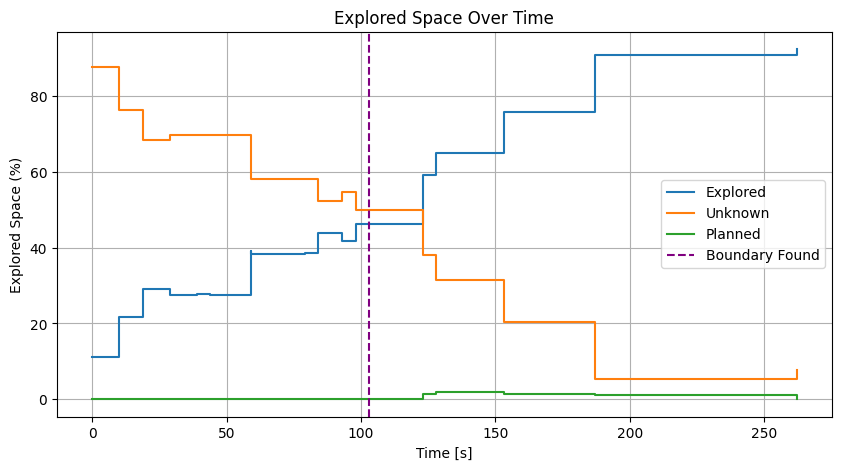

est_min [20.25998642251595, 36.866171570349124, 46.84181054865633, 53.468671473286065, 52.982660373305606, 5.210904173606867, 0.0]
est_max [37.316240092879305, 62.0293471742269, 69.98119057609487, 74.71354215144265, 74.96430333963677, 7.8266340869649325, 0.0]
est_real [36.32505212784327, 60.38217940195155, 67.86053037271475, 72.26587184192192, 72.50698836903166, 7.602639134261031, 0.0]
err_abs_min [118.74001357748405, 97.13382842965088, 62.15818945134367, 21.531328526713935, 22.017339626694394, 5.210904173606867, 0.0]
err_abs_max [101.6837599071207, 71.9706528257731, 39.018809423905125, 0.28645784855734746, 0.035696660363228716, 7.8266340869649325, 0.0]
err_abs_real [102.67494787215674, 73.61782059804845, 41.13946962728525, 2.7341281580780787, 2.49301163096834, 7.602639134261031, 0.0]
timestamp_differences [139, 134, 109, 75, 75, 0, 0]


ZeroDivisionError: float division by zero

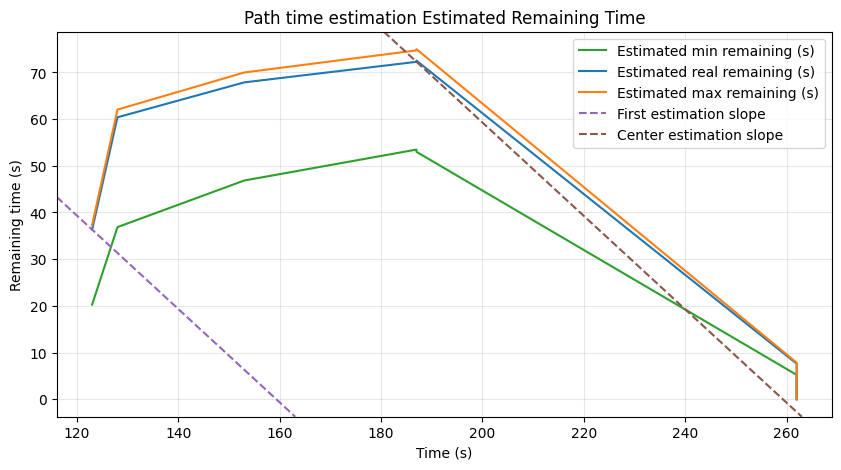

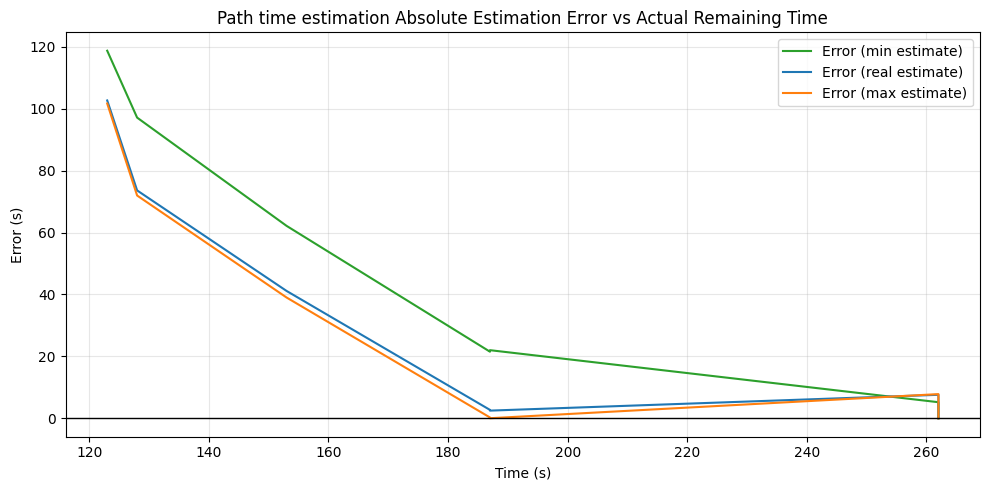

In [91]:
def path_drawing(
    grid: np.ndarray,
    raw_time: dict,
    color: int = VAL_CALCULATED_PATH
    ) -> np.ndarray:
    """
    DEPRECATED: Use path_drawing_v2.

    Args:
        grid (np.ndarray): _description_
        raw_time (dict): _description_
        color (int, optional): _description_. Defaults to VAL_CALCULATED_PATH.

    Returns:
        np.ndarray: _description_
    """
    full_path_cells = [(r, c) for targ in raw_time['targets'] for (r, c) in targ['path_cells'][1:-1]]
    for (r, c) in full_path_cells:
        grid[r, c] = color
            
    return grid
    

####################################################################################################

DIRPATH = "../maps/experiment_box_01"

filenames = [_f.name for _f in os.scandir(DIRPATH) if _f.is_file()]
filenames.sort()

maps_list = []
odom_list = []
times_list = []
timestamps = []

for _map in filenames:
    # print(_f)
    _grid, origin_x, origin_y, map_data = read_data_map(DIRPATH, _map)
    pos_x, pos_y, odom_data = read_data_odom(DIRPATH, _map)
    position = get_position(pos_x, pos_y, origin_x, origin_y)

    raw_map = read_frame(DIRPATH, _map, frame='map')
    raw_time = read_frame(DIRPATH, _map, frame='time')
    # maps_list.append(raw_map)
    odom_list.append(odom_data)
    timestamp = raw_map["header"]["stamp"]["sec"]
    timestamps.append(timestamp)

    # print_plot_v2(_grid, title="Original map")
    
    filled_grid = fill_enclosed_unknowns_v2(_grid, position)
    # fully_enclosed = is_fully_enclosed_v2(filled_grid, position)
    # print(fully_enclosed, _f)
    # print("fully_enclosed", fully_enclosed)
    # if fully_enclosed:
    #     filled_grid = fill_outside_with_val_inaccessible(filled_grid, position)
    #     print(f"Map is fully enclosed")
    
    # filled_grid = mark_position(filled_grid, pos_x, pos_y, origin_x, origin_y)
    
    filled_grid = mark_position_v2(filled_grid, position[0], position[1], VAL_CURR_POSITION)
    # _,_, goal_x, goal_y = explore_nearest_unknown(filled_grid, position[0], position[1], origin_x, origin_y)
    # if goal_x is not None and goal_y is not None:
    #     filled_grid = mark_position_v2(filled_grid, goal_x, goal_y, VAL_NEXT_GOAL)
    # else:
    #     print("No unknowns found")
    
    occupied,\
    free,\
    inaccessible,\
    unknown,\
    explored_percent = calculate_remaining_space(filled_grid)
    
    updated_grid, _ = path_drawing_v2(filled_grid, RESOLUTION_M, ROBOT_RADIUS_M, MAX_SPEED_MPS)
    # times_list.append(times_between)
    
    # updated_grid = path_drawing(filled_grid, raw_time, VAL_CALCULATED_PATH)
    
    maps_list.append(updated_grid)
    if raw_time: times_list.append(raw_time)
    
    # print_plot_v2(
    #     updated_grid,
    #     title=f"Filled map",
    #     filename=_map,
    #     occupied=occupied,
    #     free=free,
    #     inaccessible=inaccessible,
    #     unknown=unknown,
    #     explored_percent=explored_percent,
    #     position_x=pos_x,
    #     position_y=pos_y
    # )
    
    # raise Exception("Hey there is TODO down there")
    
    # break
    

print_space_in_time_changes(maps_list, timestamps)
print_estimated_time_changes_v2(times_list, timestamps, title_prefix="Path time estimation")

print(dumps(times_list, indent=4))


In [ ]:
print(timestamps)
print(times_list)

[1, 6, 6, 6, 6, 6, 11, 21, 21, 26, 31, 36, 36, 41, 46, 51, 56, 101, 146, 178, 188, 197, 204, 221, 236, 246, 261]
[{'num_future_targets': 10, 'targets': [{'start': [89, 92], 'goal': [82, 87], 'path_length_m': 0.4000000059604645, 'path_cells': [[89, 92], [88, 91], [87, 91], [86, 90], [85, 89], [84, 88], [83, 88], [82, 87]], 'min_time': 1.0752906744034076, 'max_time': 1.6504777311530083, 'real_time': 1.6051223914178336}, {'start': [82, 87], 'goal': [20, 31], 'path_length_m': 3.1500000469386578, 'path_cells': [[82, 87], [81, 86], [80, 85], [79, 84], [78, 83], [77, 82], [76, 82], [75, 81], [74, 80], [73, 79], [72, 78], [71, 77], [70, 76], [69, 75], [68, 74], [67, 73], [66, 73], [65, 72], [64, 71], [63, 70], [62, 69], [61, 68], [60, 67], [59, 66], [58, 65], [57, 64], [56, 64], [55, 63], [54, 62], [53, 61], [52, 60], [51, 59], [50, 58], [49, 57], [48, 56], [47, 55], [46, 54], [45, 54], [44, 53], [43, 52], [42, 51], [41, 50], [40, 49], [39, 48], [38, 47], [37, 46], [36, 45], [35, 45], [34, 44]

## All experiments summary

In [57]:

def get_experiments_data(prefix: str="experiment_waffle_") -> list[str]:
    """
    This method gets relative paths for all experiments in the data folder (maps).

    Args:
        prefix (str, optional): prefix of the experiment folders. Defaults to "experiment_waffle_".
    Returns:
        list: list of relative paths to all experiments
    """
    base_dir = os.path.dirname(MAPSPATH)
    print("Base dir:", base_dir)
    experiment_dirs = []
    for entry in os.scandir(base_dir):
        if entry.is_dir() and entry.name.startswith(prefix):
            experiment_dirs.append(os.path.join(base_dir, entry.name))
    return experiment_dirs

def all_experiments_summary(dir_name: str, print_all: bool = False, debug: bool = False) -> tuple[list[np.ndarray], list[dict], list[dict], list[int]]:
    filenames = [_f.name for _f in os.scandir(dir_name) if _f.is_file()]
    filenames.sort()

    maps_list = []
    odom_list = []
    times_list = []
    timestamps = []

    if debug:
        print("Processing directory:", dir_name)
        print("Found files:", filenames)
    
    for _map in filenames:
        _grid, origin_x, origin_y, map_data = read_data_map(dir_name, _map)
        pos_x, pos_y, odom_data = read_data_odom(dir_name, _map)
        position = get_position(pos_x, pos_y, origin_x, origin_y)

        raw_map = read_frame(dir_name, _map, frame='map')
        raw_time = read_frame(dir_name, _map, frame='time')
        odom_list.append(odom_data)
        timestamp = raw_map["header"]["stamp"]["sec"]
        timestamps.append(timestamp)

        filled_grid = fill_enclosed_unknowns_v2(_grid, position)
        filled_grid = mark_position_v2(filled_grid, position[0], position[1], VAL_CURR_POSITION)
        
        occupied,\
        free,\
        inaccessible,\
        unknown,\
        explored_percent = calculate_remaining_space(filled_grid)
        
        updated_grid, _ = path_drawing_v2(filled_grid, RESOLUTION_M, ROBOT_RADIUS_M, MAX_SPEED_MPS)
        
        maps_list.append(updated_grid)
        if raw_time: times_list.append(raw_time)

        # if print_all:
        #     print_plot_v2(
        #         updated_grid,
        #         title=f"Filled map",
        #         filename=_map,
        #         occupied=occupied,
        #         free=free,
        #         inaccessible=inaccessible,
        #         unknown=unknown,
        #         explored_percent=explored_percent,
        #         position_x=pos_x,
        #         position_y=pos_y
        #     )
        
        # raise Exception("Hey there is TODO down there")
        
        # break
        
    if print_all:
        print_space_in_time_changes(maps_list, timestamps)
        print_estimated_time_changes_v2(times_list, timestamps, title_prefix="Path time estimation")

        print(dumps(times_list, indent=4))
    
    return maps_list, odom_list, times_list, timestamps
    
print(get_experiments_data())

Base dir: ../maps
['../maps/experiment_waffle_01', '../maps/experiment_waffle_05', '../maps/experiment_waffle_06', '../maps/experiment_waffle_02', '../maps/experiment_waffle_04', '../maps/experiment_waffle_00', '../maps/experiment_waffle_03']


Base dir: ../maps
Processing experiment in ../maps/experiment_waffle_00
Processing directory: ../maps/experiment_waffle_00
Found files: ['map_odom_20250914_160837_254096.json', 'map_odom_20250914_160844_194283.json', 'map_odom_20250914_160844_368170.json', 'map_odom_20250914_160845_684648.json', 'map_odom_20250914_160845_826906.json', 'map_odom_20250914_160847_087088.json', 'map_odom_20250914_160848_341604.json', 'map_odom_20250914_160859_590188.json', 'map_odom_20250914_160904_716553.json', 'map_odom_20250914_160909_848763.json', 'map_odom_20250914_160913_371723.json', 'map_odom_20250914_160921_109112.json', 'map_odom_20250914_161007_252550.json', 'map_odom_20250914_161049_819800.json', 'map_odom_20250914_161055_877466.json', 'map_odom_20250914_161100_362713.json', 'map_odom_20250914_161123_912000.json', 'map_odom_20250914_161153_246106.json', 'map_odom_20250914_161207_653878.json', 'map_odom_20250914_161229_321990.json']
No data found in the map_odom_20250914_160837_254096.json.time 

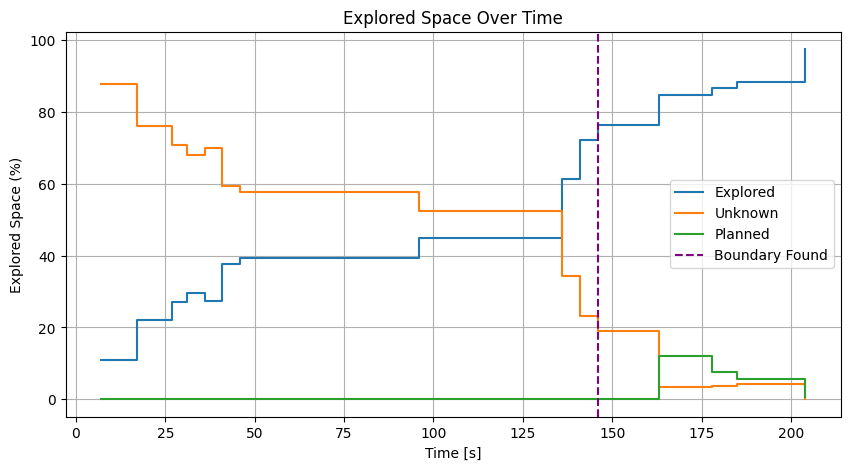

est_min [27.332895778633116, 35.21186459809053, 37.58766110277134, 0.0]
est_max [38.97156803137827, 57.12930123350097, 66.4668610271713, 0.0]
est_real [37.826090742161796, 55.61169190438333, 64.40433790964735, 0.0]
err_abs_min [13.667104221366884, 9.211864598090528, 18.587661102771342, 0.0]
err_abs_max [2.0284319686217316, 31.129301233500968, 47.466861027171305, 0.0]
err_abs_real [3.173909257838204, 29.611691904383328, 45.40433790964735, 0.0]
timestamp_differences [41, 26, 19, 0]
err_abs_min [33.33440053991923, 35.43024845419434, 97.8297952777439, 0]
err_abs_max [4.947395045418858, 119.72808166731141, 249.82558435353317, 0]
err_abs_real [7.741242092288303, 113.89112270916664, 238.97019952445976, 0]
timestamp_differences [41, 26, 19, 0]
[
    {
        "num_future_targets": 10,
        "targets": [
            {
                "start": [
                    5,
                    63
                ],
                "goal": [
                    57,
                    100
           

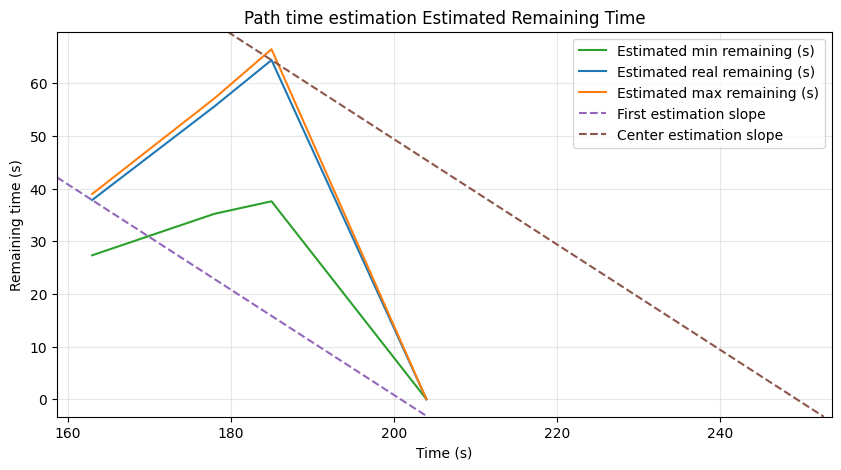

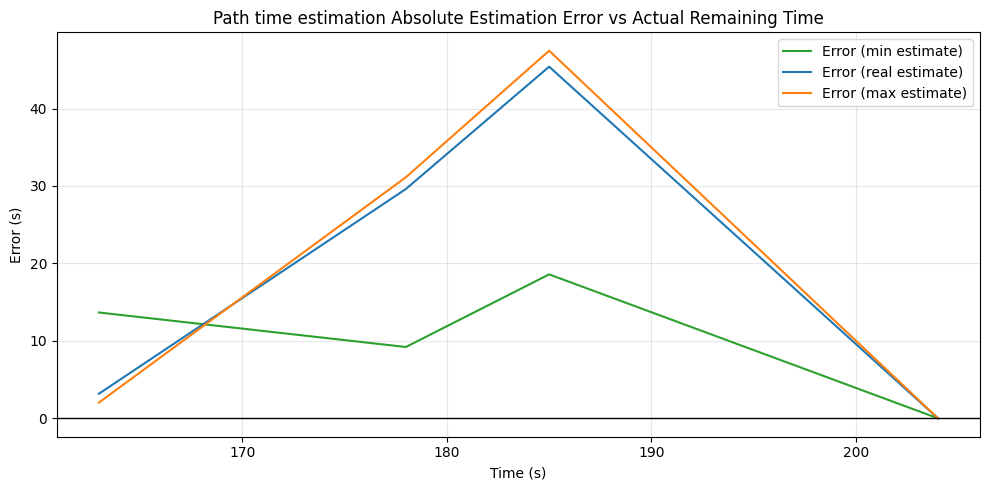

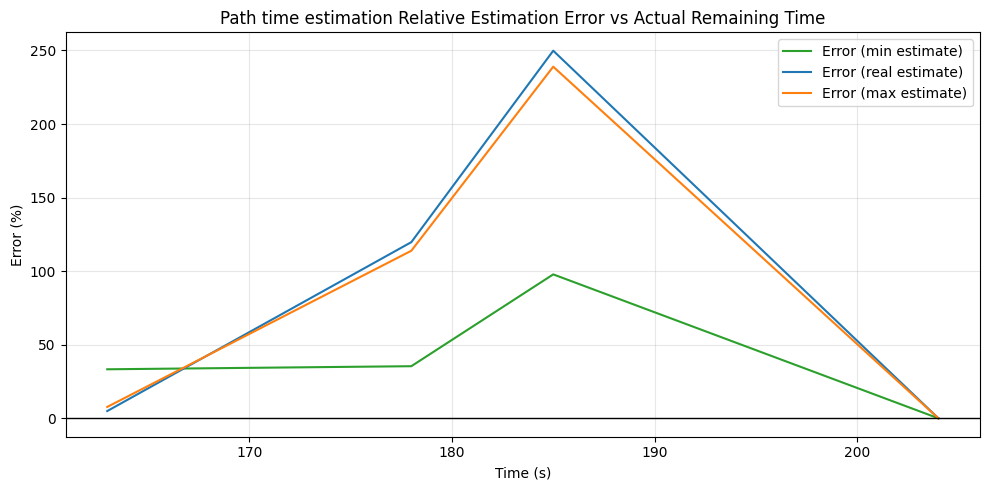

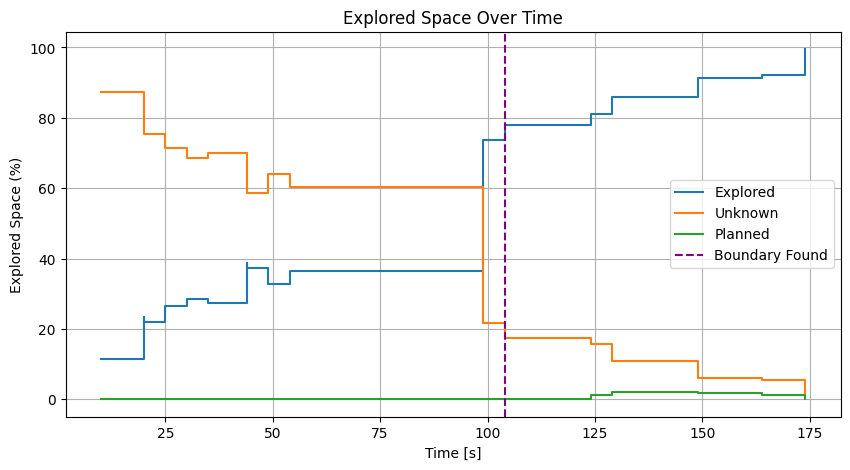

est_min [37.385458980648544, 20.35624728106665, 12.79937359254185, 21.549285167720022, 0.0]
est_max [57.27875482297175, 58.736477644884886, 17.40126812450314, 31.423352467934304, 0.0]
est_real [55.70102355987003, 56.75378208912342, 16.867922878764116, 30.45944372391834, 0.0]
err_abs_min [12.614541019351456, 24.64375271893335, 12.20062640745815, 11.549285167720022, 0.0]
err_abs_max [7.278754822971749, 13.736477644884886, 7.59873187549686, 21.423352467934304, 0.0]
err_abs_real [5.7010235598700305, 11.753782089123419, 8.132077121235884, 20.45944372391834, 0.0]
timestamp_differences [50, 45, 25, 10, 0]
err_abs_min [25.22908203870291, 54.763894930963, 48.8025056298326, 115.49285167720022, 0]
err_abs_max [14.557509645943497, 30.52550587752197, 30.39492750198744, 214.23352467934302, 0]
err_abs_real [11.402047119740061, 26.119515753607597, 32.52830848494354, 204.59443723918343, 0]
timestamp_differences [50, 45, 25, 10, 0]
[
    {
        "num_future_targets": 10,
        "targets": [
         

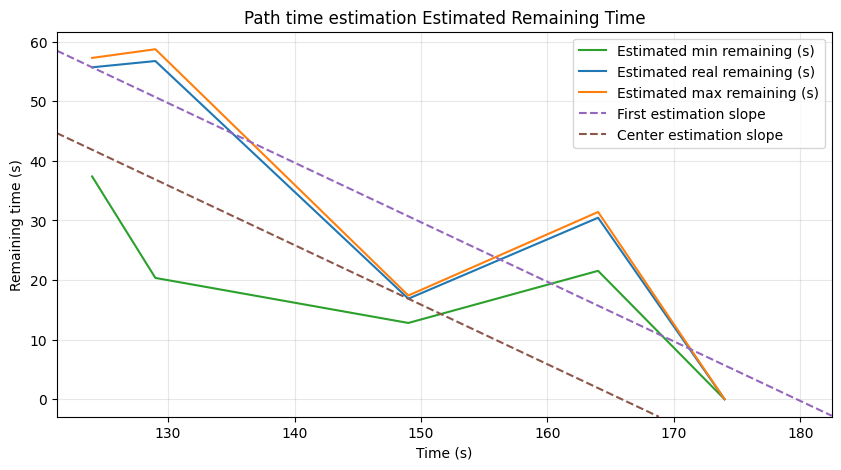

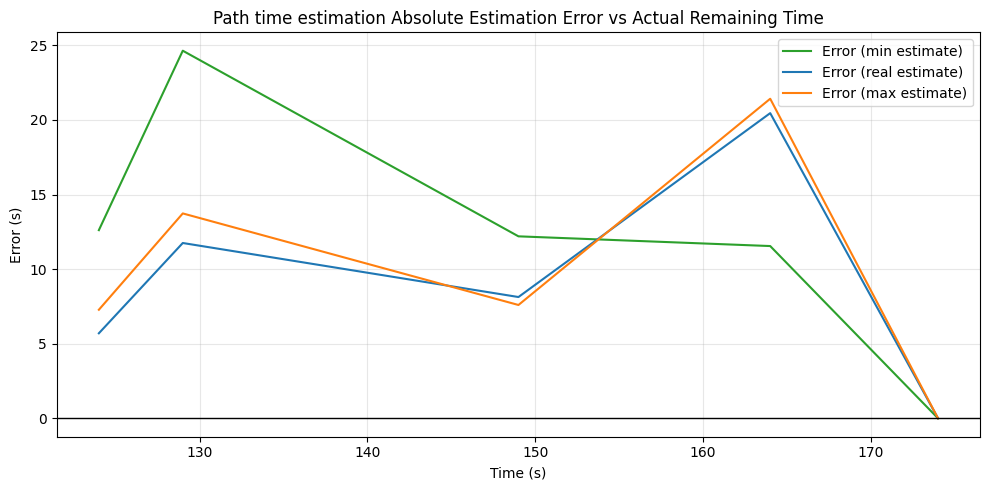

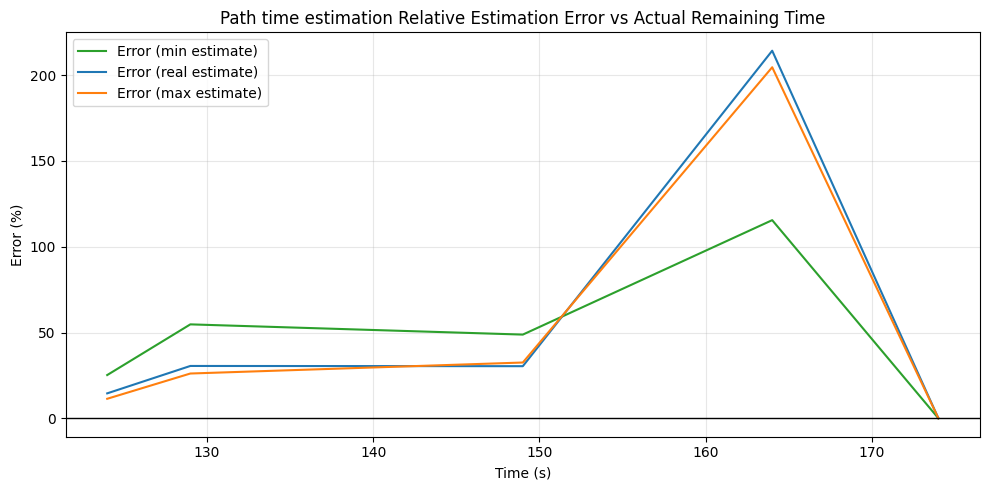

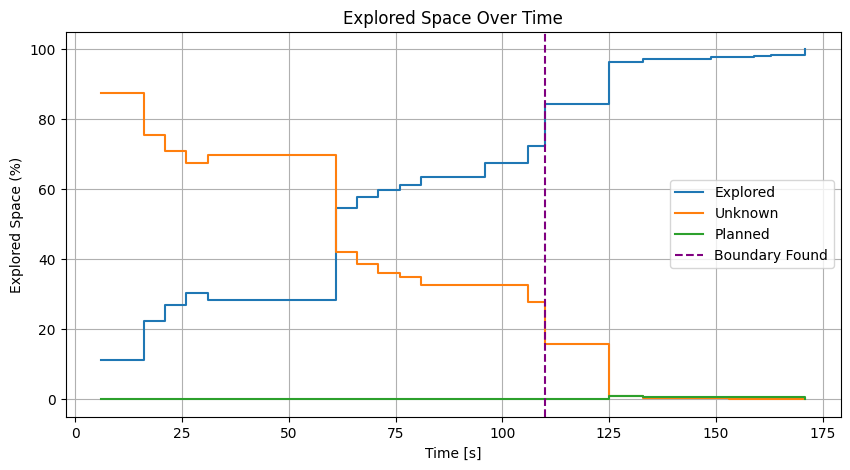

est_min [35.16295594504587, 27.619002775872836, 23.73628356085588, 27.260098081307294, 27.260098081307294, 24.513118126490532, 24.518317448917045, 0.0]
est_max [51.331191461525904, 43.681017661909756, 40.05770301356268, 43.35137751750083, 43.35137751750083, 33.39390620909164, 33.683373422021766, 0.0]
est_real [49.72393747013181, 42.24112911333667, 38.838733299201905, 41.9694788685241, 41.9694788685241, 32.34514465006889, 32.63254079515629, 0.0]
err_abs_min [10.837044054954127, 10.380997224127164, 1.736283560855881, 9.260098081307294, 9.260098081307294, 12.513118126490532, 16.518317448917045, 0.0]
err_abs_max [5.331191461525904, 5.681017661909756, 18.05770301356268, 25.35137751750083, 25.35137751750083, 21.39390620909164, 25.683373422021766, 0.0]
err_abs_real [3.7239374701318084, 4.241129113336669, 16.838733299201905, 23.9694788685241, 23.9694788685241, 20.34514465006889, 24.632540795156288, 0.0]
timestamp_differences [46, 38, 22, 18, 18, 12, 8, 0]
err_abs_min [23.558791423813318, 27.31

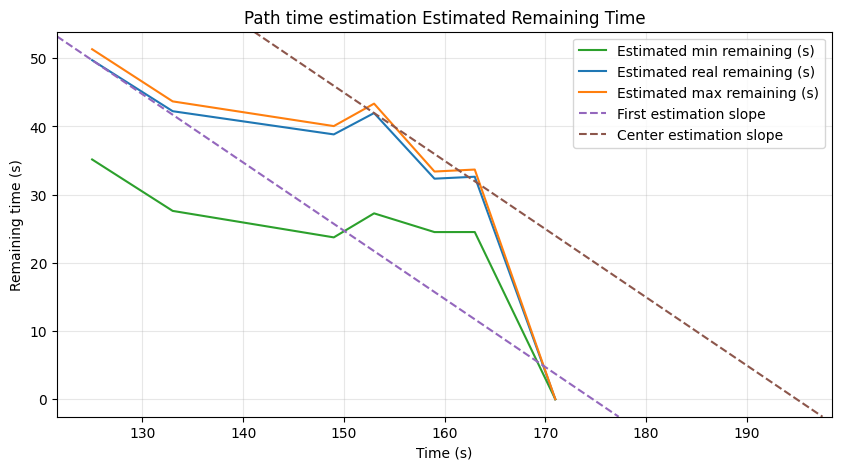

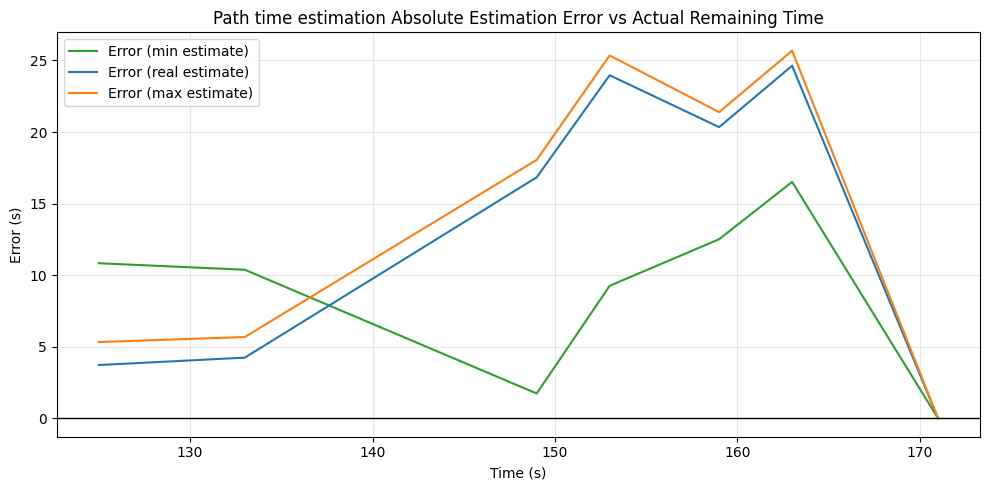

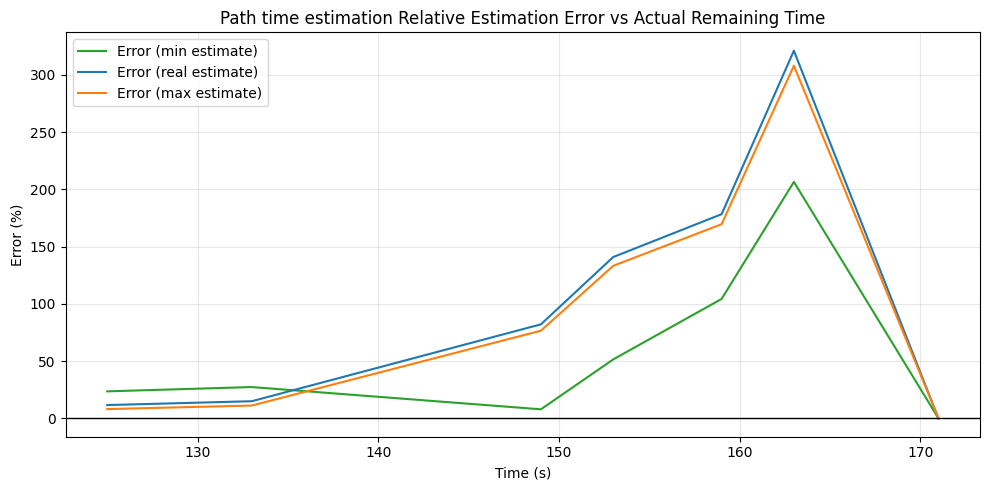

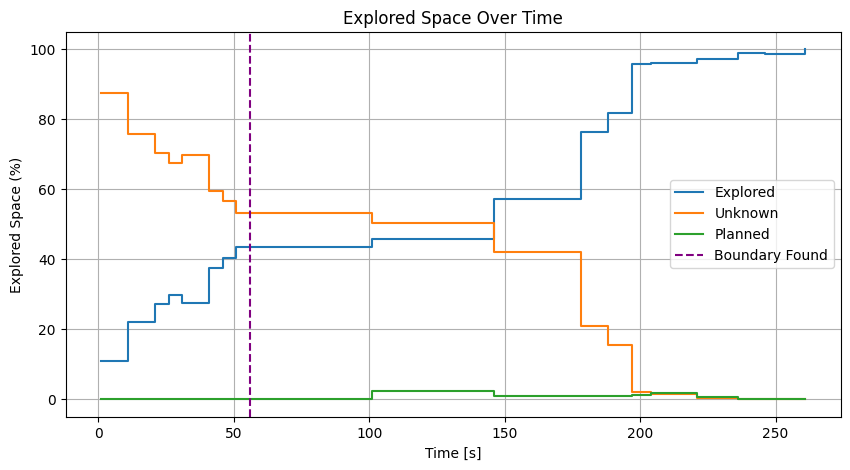

est_min [25.419888685916636, 46.96032759651974, 24.811280591802074, 25.573791477182233, 21.618559655287136, 12.143083605039724, 29.583408296955806, 14.425041171563711, 16.387445076905276, 0.0]
est_max [33.55949514217233, 73.9953210909492, 53.51034625052847, 69.31341098091532, 48.91121234587595, 17.349555553045658, 47.43478179931159, 18.083893900289105, 20.3831118296821, 0.0]
est_real [32.50889592128146, 71.99667099065492, 51.7286557483961, 67.12781174311162, 47.39703447431454, 16.840854968614536, 45.85051770699228, 17.447264381763564, 19.65805085233375, 0.0]
err_abs_min [134.58011131408335, 68.03967240348027, 58.188719408197926, 47.42620852281777, 42.381440344712864, 44.85691639496028, 10.416591703044194, 10.574958828436289, 1.3874450769052764, 0.0]
err_abs_max [126.44050485782768, 41.004678909050796, 29.48965374947153, 3.6865890190846784, 15.088787654124047, 39.65044444695434, 7.434781799311587, 6.916106099710895, 5.3831118296821, 0.0]
err_abs_real [127.49110407871854, 43.003329009345

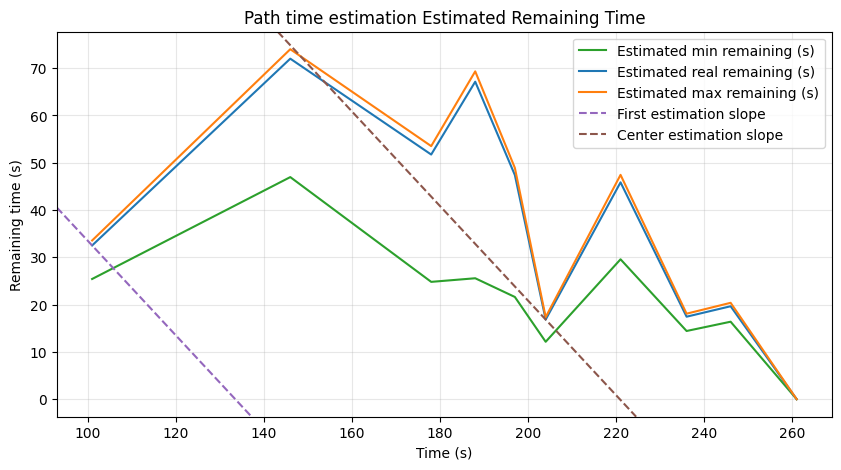

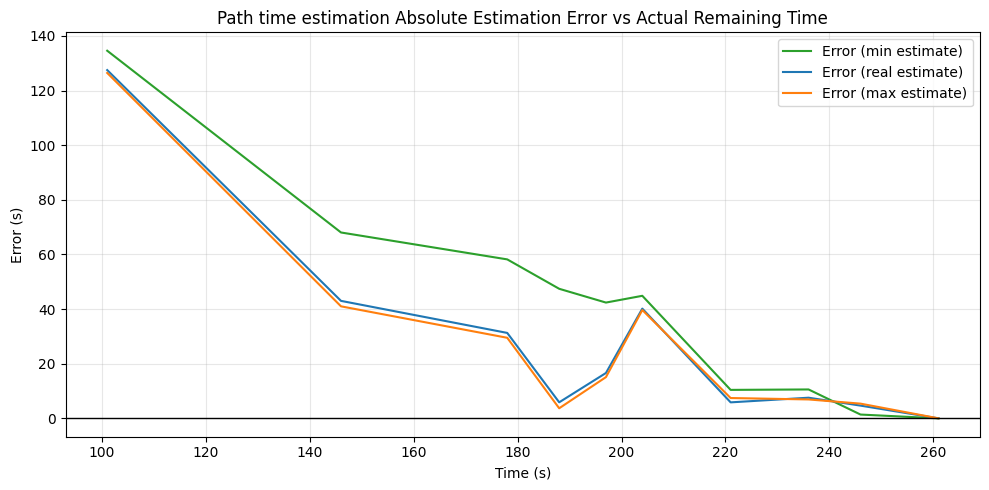

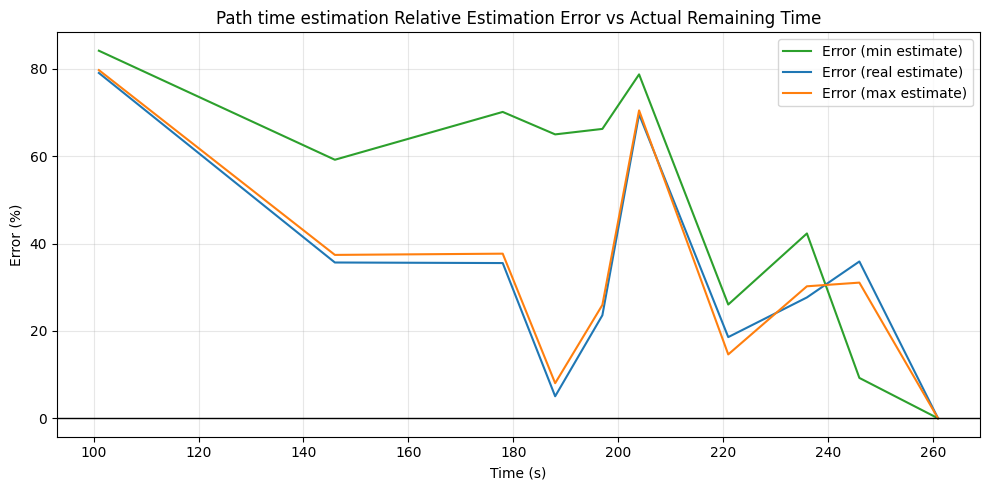

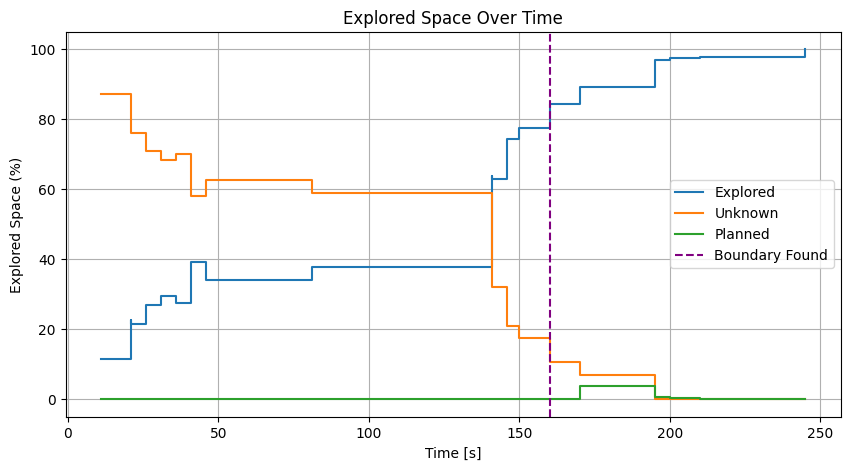

est_min [12.59686792897275, 33.49932395467282, 33.49932395467282, 22.06828951275832, 20.691670201647753, 0.0]
est_max [19.451102900575187, 92.4996645158428, 92.4996645158428, 75.02393580361503, 81.38102992697956, 0.0]
est_real [18.920478434263124, 89.45400429867911, 89.45400429867911, 72.49182898469715, 78.57723262843007, 0.0]
err_abs_min [62.40313207102725, 16.500676045327182, 16.500676045327182, 22.93171048724168, 14.308329798352247, 0.0]
err_abs_max [55.54889709942481, 42.499664515842795, 42.499664515842795, 30.023935803615032, 46.381029926979565, 0.0]
err_abs_real [56.079521565736876, 39.45400429867911, 39.45400429867911, 27.49182898469715, 43.57723262843007, 0.0]
timestamp_differences [75, 50, 50, 45, 35, 0]
err_abs_min [83.204176094703, 33.001352090654365, 33.001352090654365, 50.959356638314844, 40.88094228100642, 0]
err_abs_max [74.06519613256641, 84.99932903168559, 84.99932903168559, 66.71985734136673, 132.51722836279876, 0]
err_abs_real [74.7726954209825, 78.90800859735822, 78

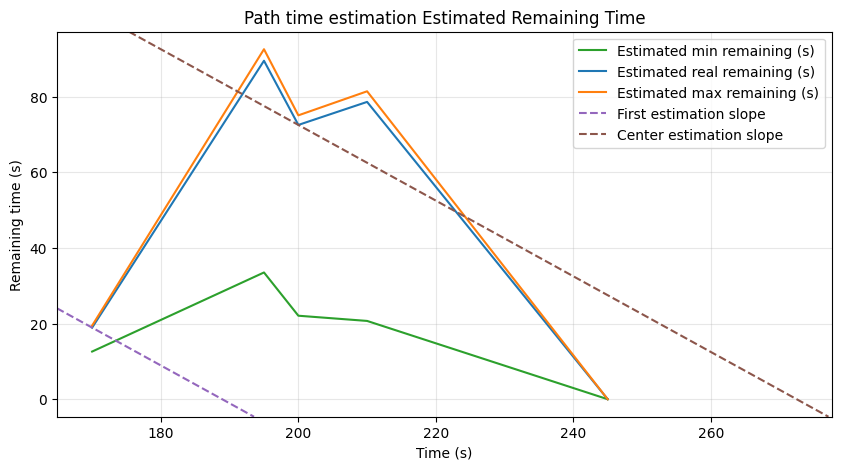

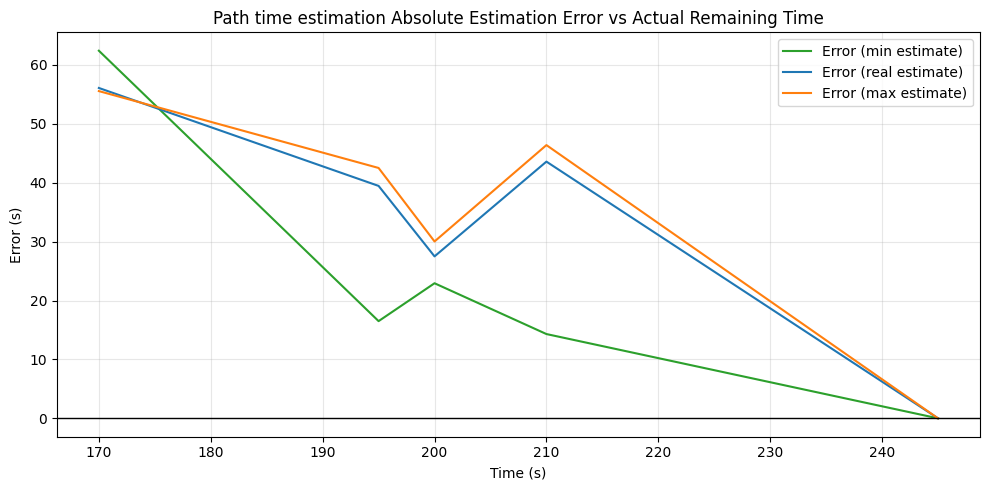

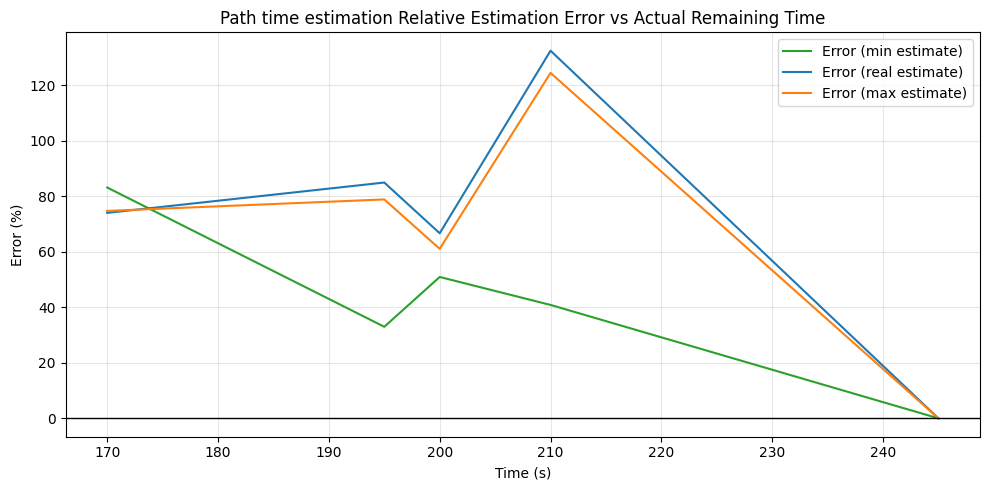

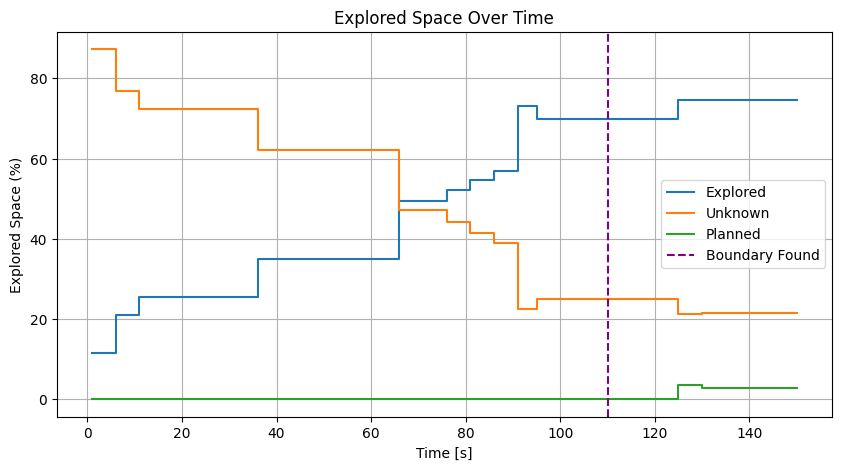

est_min [10.107541487863989, 17.76031354415642, 0.0]
est_max [15.9486974220684, 26.591107033858055, 0.0]
est_real [15.521062856023244, 25.844771886213003, 0.0]
err_abs_min [14.892458512136011, 2.2396864558435787, 0.0]
err_abs_max [9.0513025779316, 6.591107033858055, 0.0]
err_abs_real [9.478937143976756, 5.844771886213003, 0.0]
timestamp_differences [25, 20, 0]
err_abs_min [59.569834048544045, 11.198432279217894, 0]
err_abs_max [36.2052103117264, 32.95553516929027, 0]
err_abs_real [37.915748575907024, 29.223859431065012, 0]
timestamp_differences [25, 20, 0]
[
    {
        "num_future_targets": 10,
        "targets": [
            {
                "start": [
                    68,
                    89
                ],
                "goal": [
                    61,
                    89
                ],
                "path_length_m": 0.4000000059604645,
                "path_cells": [
                    [
                        68,
                        89
             

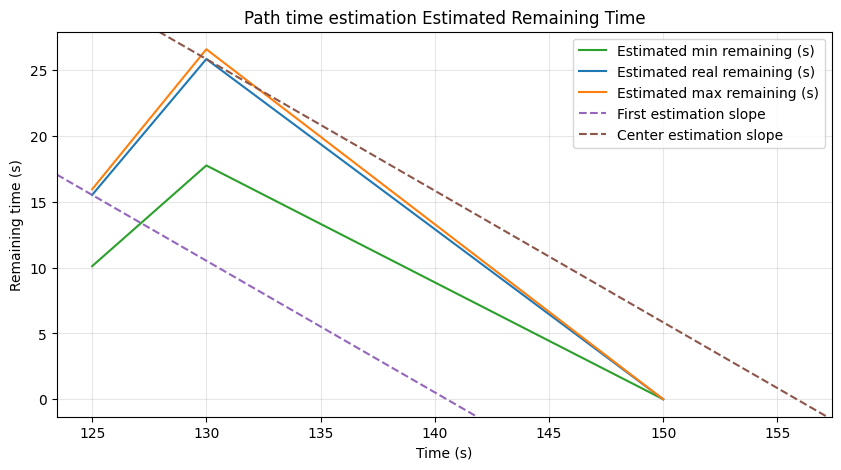

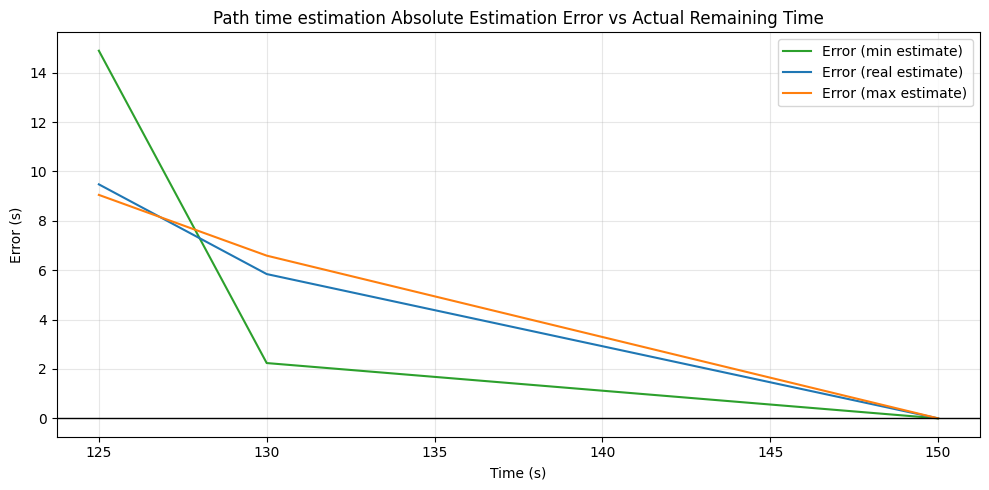

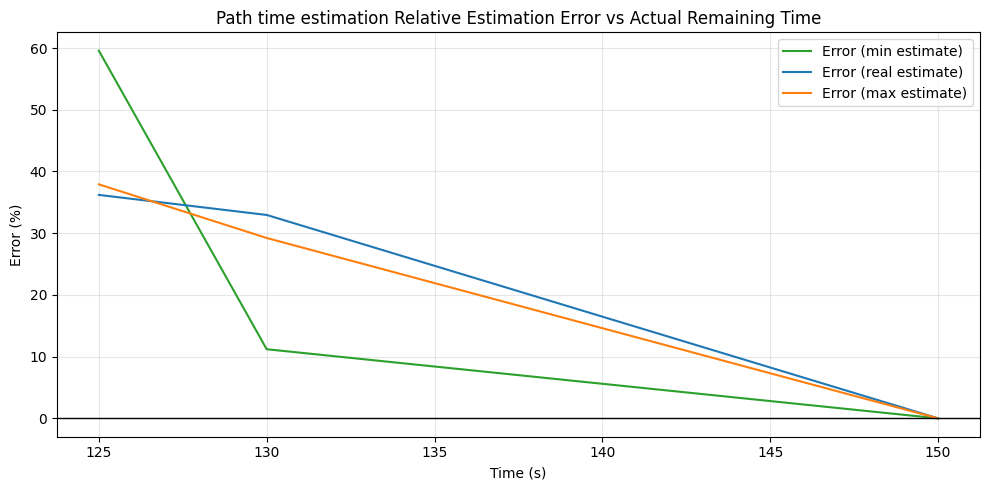

In [92]:
all_experiments_data = []

for dir_name in sorted(get_experiments_data()):
    print(f"Processing experiment in {dir_name}")
    maps_list, odom_list, times_list, timestamps = all_experiments_summary(dir_name, debug=True, print_all=True)
    all_experiments_data.append({
        "maps": [l.tolist() for l in maps_list],
        "odom": odom_list,
        "times": times_list,
        "timestamps": timestamps
    })

# print(dumps(all_experiments_data, indent=4))

with open("waffle_json_results.json", "w+") as f:
    f.write(dumps(all_experiments_data, indent=4))
    f.close()

In [ ]:
# from exploration_analysis import (
#     extract_timeseries_from_json, compute_eta_time, summarize_eta_by_method, summarize_runs,
#     plot_eta_boxplot_by_method, plot_pred_vs_actual_scatter, plot_error_histogram,
#     plot_calibration_curve, plot_eta_by_coverage_bin, plot_runtime_cdf,
#     plot_coverage_over_time_for_run, hypothesis_check_report
# )

# # 1) Load & tidy from your JSON
# ts = extract_timeseries_from_json("../waffle_json_results.json")

# # 2) Compute eta% and summary against your 60% threshold
# eta_df = compute_eta_time(ts)
# summary = summarize_eta_by_method(eta_df, threshold=0.60)
# summary  # <- table of results to cite in the thesis

# # 3) (Optional) Plots for the thesis
# plot_eta_boxplot_by_method(eta_df)
# plot_pred_vs_actual_scatter(eta_df)
# plot_error_histogram(eta_df)
# plot_calibration_curve(eta_df)
# plot_eta_by_coverage_bin(eta_df)

# # 4) (Optional) runtime CDF per method
# run_summary = summarize_runs(ts)
# plot_runtime_cdf(run_summary)

# # 5) (Optional) single-run coverage trace
# # plot_coverage_over_time_for_run(ts, run_id="run_0")
